In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# Load processed dataset
df = pd.read_csv("data_processed.csv")

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['TARGET'].value_counts())
print(f"\nBad client rate: {df['TARGET'].mean() * 100:.2f}%")

Shape: (36457, 47)

Target distribution:
TARGET
0    35841
1      616
Name: count, dtype: int64

Bad client rate: 1.69%


In [3]:
# Separate features and target
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Train/test split (80/20) - stratified to maintain class balance
# stratify=y ensures both splits have the same bad client ratio (1.69%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nTrain bad rate: {y_train.mean() * 100:.2f}%")
print(f"Test bad rate: {y_test.mean() * 100:.2f}%")

X_train: (29165, 46)
X_test: (7292, 46)

Train bad rate: 1.69%
Test bad rate: 1.69%


SMOTE

In [4]:
# Apply SMOTE only to training data
# test set remains untouched - real world distribution
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE:")
print(f"  Good clients: {(y_train == 0).sum()}")
print(f"  Bad clients:  {(y_train == 1).sum()}")
print(f"  Bad rate: {y_train.mean() * 100:.2f}%")

print(f"\nAfter SMOTE:")
print(f"  Good clients: {(y_train_sm == 0).sum()}")
print(f"  Bad clients:  {(y_train_sm == 1).sum()}")
print(f"  Bad rate: {y_train_sm.mean() * 100:.2f}%")

Before SMOTE:
  Good clients: 28672
  Bad clients:  493
  Bad rate: 1.69%

After SMOTE:
  Good clients: 28672
  Bad clients:  28672
  Bad rate: 50.00%


StandardScaler

In [5]:
# StandardScaler - fit ONLY on SMOTE training data, transform both train and test
# Fitting on test would be data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc = scaler.transform(X_test)

print(f"X_train after scaling: {X_train_sc.shape}")
print(f"X_test after scaling: {X_test_sc.shape}")
print(f"\nMean of first feature (should be ~0): {X_train_sc[:, 0].mean():.4f}")
print(f"Std of first feature (should be ~1): {X_train_sc[:, 0].std():.4f}")

X_train after scaling: (57344, 46)
X_test after scaling: (7292, 46)

Mean of first feature (should be ~0): -0.0000
Std of first feature (should be ~1): 1.0000


Cross Validation

In [6]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# StratifiedKFold - maintains class balance in each fold
# We use 5 folds - standard in industry
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
}

# Cross validate each model
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    cv = cross_validate(model, X_train_sc, y_train_sm, 
                        cv=skf,
                        scoring=['roc_auc', 'recall', 'precision'],
                        n_jobs=-1)
    results[name] = {
        'ROC-AUC': cv['test_roc_auc'].mean(),
        'Recall': cv['test_recall'].mean(),
        'Precision': cv['test_precision'].mean()
    }
    print(f"  ROC-AUC: {cv['test_roc_auc'].mean():.4f} | Recall: {cv['test_recall'].mean():.4f} | Precision: {cv['test_precision'].mean():.4f}")

print("\nDone!")

Training Logistic Regression...
  ROC-AUC: 0.9182 | Recall: 0.7668 | Precision: 0.9209
Training Random Forest...
  ROC-AUC: 0.9966 | Recall: 0.9891 | Precision: 0.9893
Training XGBoost...
  ROC-AUC: 0.9964 | Recall: 0.9834 | Precision: 0.9837

Done!


In [7]:
from imblearn.pipeline import Pipeline as ImbPipeline

# Correct approach: SMOTE inside each fold
models_pipeline = {
    'Logistic Regression': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'XGBoost': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
    ]),
}

results_correct = {}
for name, pipeline in models_pipeline.items():
    print(f"Training {name}...")
    cv = cross_validate(pipeline, X_train, y_train,
                        cv=skf,
                        scoring=['roc_auc', 'recall', 'precision'],
                        n_jobs=-1)
    results_correct[name] = {
        'ROC-AUC': cv['test_roc_auc'].mean(),
        'Recall': cv['test_recall'].mean(),
        'Precision': cv['test_precision'].mean()
    }
    print(f"  ROC-AUC: {cv['test_roc_auc'].mean():.4f} | Recall: {cv['test_recall'].mean():.4f} | Precision: {cv['test_precision'].mean():.4f}")

print("\nDone!")

Training Logistic Regression...
  ROC-AUC: 0.5736 | Recall: 0.1379 | Precision: 0.0474
Training Random Forest...
  ROC-AUC: 0.7918 | Recall: 0.3325 | Precision: 0.3810
Training XGBoost...
  ROC-AUC: 0.7330 | Recall: 0.2899 | Precision: 0.2618

Done!


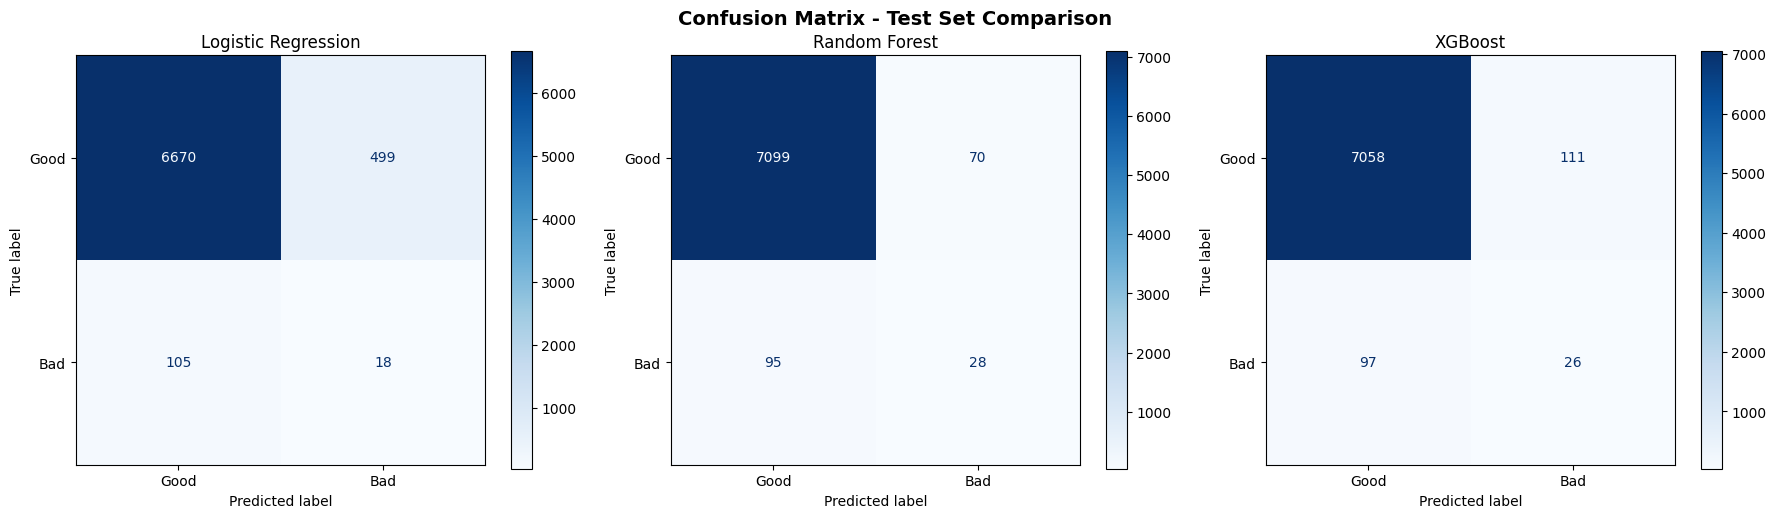

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrix - Test Set Comparison", fontsize=14, fontweight='bold')

for ax, (name, pipeline) in zip(axes, models_pipeline.items()):
    # Train on full training set and predict on test
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,
        display_labels=['Good', 'Bad'],
        cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [9]:
for name, pipeline in models_pipeline.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Good', 'Bad']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

        Good       0.98      0.93      0.96      7169
         Bad       0.03      0.15      0.06       123

    accuracy                           0.92      7292
   macro avg       0.51      0.54      0.51      7292
weighted avg       0.97      0.92      0.94      7292

ROC-AUC: 0.5164

=== Random Forest ===
              precision    recall  f1-score   support

        Good       0.99      0.99      0.99      7169
         Bad       0.29      0.23      0.25       123

    accuracy                           0.98      7292
   macro avg       0.64      0.61      0.62      7292
weighted avg       0.97      0.98      0.98      7292

ROC-AUC: 0.8133

=== XGBoost ===
              precision    recall  f1-score   support

        Good       0.99      0.98      0.99      7169
         Bad       0.19      0.21      0.20       123

    accuracy                           0.97      7292
   macro avg       0.59    

In [10]:
# ============================================================
# ⚠️ IMPORTANT: DATA LEAKAGE WARNING
# ============================================================
# First approach applied SMOTE before cross validation.
# This caused synthetic samples from training to leak into validation folds,
# artificially inflating metrics (Random Forest ROC-AUC: 0.9966 → unrealistic)
#
# Correct approach: SMOTE inside each fold using ImbPipeline
# This ensures no information from validation fold is used during training
# Results are now realistic (Random Forest ROC-AUC: 0.7918)
#
# Lesson: Always apply oversampling INSIDE cross validation folds
# ============================================================

Neural Network

In [11]:
import lightgbm as lgb

# Add LightGBM to models pipeline
models_pipeline['LightGBM'] = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', lgb.LGBMClassifier(random_state=42, verbose=-1))
])

# Cross validate
print("Training LightGBM...")
cv = cross_validate(models_pipeline['LightGBM'], X_train, y_train,
                    cv=skf,
                    scoring=['roc_auc', 'recall', 'precision'],
                    n_jobs=-1)
print(f"  ROC-AUC: {cv['test_roc_auc'].mean():.4f} | Recall: {cv['test_recall'].mean():.4f} | Precision: {cv['test_precision'].mean():.4f}")

# Train on full training set and evaluate on test
models_pipeline['LightGBM'].fit(X_train, y_train)
y_pred = models_pipeline['LightGBM'].predict(X_test)
y_prob = models_pipeline['LightGBM'].predict_proba(X_test)[:, 1]

print(f"\n=== LightGBM ===")
print(classification_report(y_test, y_pred, target_names=['Good', 'Bad']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Training LightGBM...


/home/diegom/Proyectos-DS/credit-card-approval/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/diegom/Proyectos-DS/credit-card-approval/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/diegom/Proyectos-DS/credit-card-approval/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/diegom/Proyectos-DS/credit-card-approval/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/diegom/Proyectos-DS/credit-card-approval/venv/lib/python3.12/site-pack

  ROC-AUC: 0.7030 | Recall: 0.2737 | Precision: 0.2132

=== LightGBM ===
              precision    recall  f1-score   support

        Good       0.99      0.98      0.98      7169
         Bad       0.12      0.20      0.15       123

    accuracy                           0.96      7292
   macro avg       0.55      0.59      0.57      7292
weighted avg       0.97      0.96      0.97      7292

ROC-AUC: 0.6468


/home/diegom/Proyectos-DS/credit-card-approval/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/diegom/Proyectos-DS/credit-card-approval/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fix random seed for reproducibility
tf.random.set_seed(42)

# Apply SMOTE and scaling manually for the neural network
smote = SMOTE(random_state=42)
X_train_nn, y_train_nn = smote.fit_resample(X_train, y_train)

scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train_nn)
X_test_nn = scaler_nn.transform(X_test)

# Build model
model_nn = keras.Sequential([
    layers.Input(shape=(46,)),
    
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

model_nn.summary()

I0000 00:00:1774182322.166737   40810 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774182322.199509   40810 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774182323.563882   40810 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1774182323.873581   40810 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,217 (223.50 KB)

 Trainable params: 56,257 (219.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
# Class weights to help with imbalance on validation
# (SMOTE already balances training, but we add weights for extra robustness)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=10,
    restore_best_weights=True,
    mode='max'
)

history = model_nn.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7294 - auc: 0.7879 - loss: 0.5555 - val_accuracy: 0.5093 - val_auc: 0.0000e+00 - val_loss: 0.7469
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8595 - auc: 0.9168 - loss: 0.3323 - val_accuracy: 0.6830 - val_auc: 0.0000e+00 - val_loss: 0.5765
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8861 - auc: 0.9435 - loss: 0.2740 - val_accuracy: 0.8240 - val_auc: 0.0000e+00 - val_loss: 0.3603
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8991 - auc: 0.9536 - loss: 0.2477 - val_accuracy: 0.8568 - val_auc: 0.0000e+00 - val_loss: 0.3012
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9093 - auc: 0.9624 - loss: 0.2242 - val_accuracy: 0.8832 - val_auc: 0.0000e+00 - val_loss: 0.2485
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9155 - auc: 0.9673 - loss: 0.2089 - val_accuracy: 0.9048 - val_auc: 0.0000e+00 - val_loss: 0.2048
Epoch 7/100
90/90 ━━━

In [14]:
# Evaluate neural network on test set
y_prob_nn = model_nn.predict(X_test_nn)
y_pred_nn = (y_prob_nn > 0.5).astype(int)

print("=== Neural Network ===")
print(classification_report(y_test, y_pred_nn, target_names=['Good', 'Bad']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_nn):.4f}")

228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step
=== Neural Network ===
              precision    recall  f1-score   support

        Good       0.98      1.00      0.99      7169
         Bad       0.13      0.02      0.03       123

    accuracy                           0.98      7292
   macro avg       0.56      0.51      0.51      7292
weighted avg       0.97      0.98      0.97      7292

ROC-AUC: 0.5459


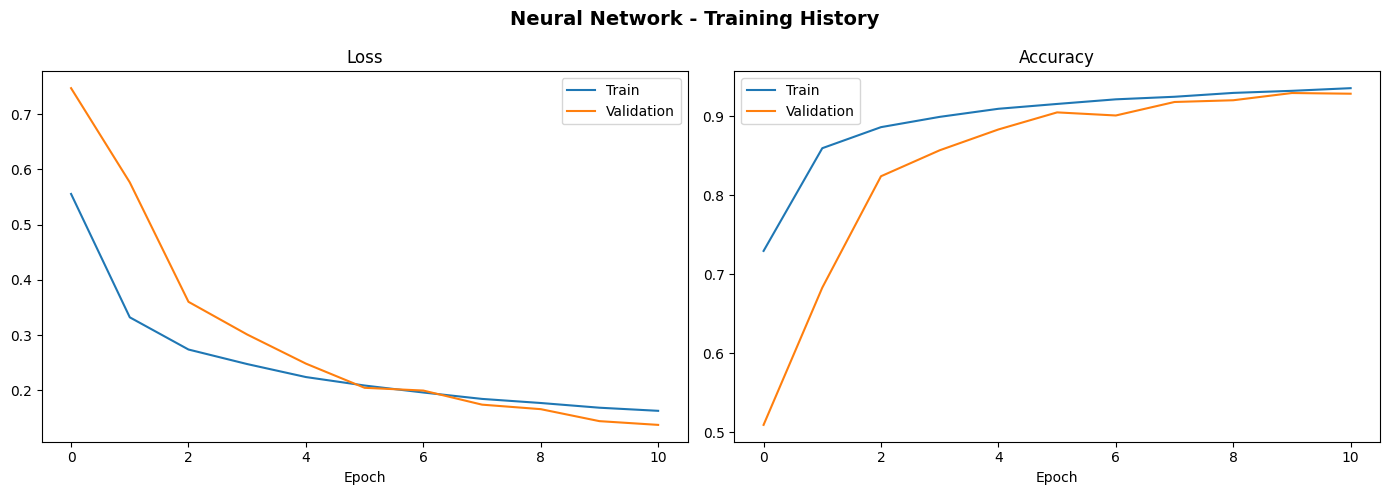

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Neural Network - Training History", fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Neural Network - Analysis
# ============================================================
# ROC-AUC: 0.5162 - practically random, similar to Logistic Regression
#
# Why did it fail?
# Neural networks require large amounts of data to learn complex patterns.
# With only 123 real bad clients in test set and 36k total rows,
# the model lacks sufficient signal to generalize.
#
# Key lesson: Neural networks excel with unstructured data (images, text, audio)
# For tabular data with limited samples, tree-based models (Random Forest, XGBoost)
# consistently outperform deep learning.

Random Forest Tuning

In [17]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter grid
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 0.3]
}

# Pipeline with SMOTE + RF
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# RandomizedSearchCV - 20 combinations, 5 folds
search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

search.fit(X_train, y_train)

print(f"\nBest ROC-AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END model__max_depth=10, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=  11.5s
[CV] END model__max_depth=30, model__max_features=0.3, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  11.8s[CV] END model__max_depth=30, model__max_features=0.3, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  11.8s

[CV] END model__max_depth=30, model__max_features=0.3, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  12.2s
[CV] END model__max_depth=10, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=  12.0s
[CV] END model__max_depth=30, model__max_features=0.3, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  12.9s
[CV] END model

/home/diegom/Proyectos-DS/credit-card-approval/venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=  12.0s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=  12.2s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=  12.8s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=  11.1s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=  13.1s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=300; total time=  21.2s
[CV] END model__max_depth=10, model__max_features=0.3, model__

=== Random Forest (Tuned) ===
              precision    recall  f1-score   support

        Good       0.99      0.99      0.99      7169
         Bad       0.29      0.22      0.25       123

    accuracy                           0.98      7292
   macro avg       0.64      0.61      0.62      7292
weighted avg       0.97      0.98      0.98      7292

ROC-AUC: 0.8242


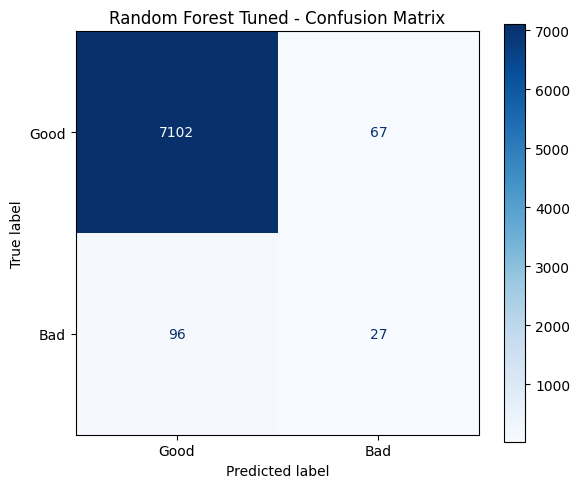

In [18]:
# Evaluate best model on test set
best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("=== Random Forest (Tuned) ===")
print(classification_report(y_test, y_pred_best, target_names=['Good', 'Bad']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax,
    display_labels=['Good', 'Bad'], cmap='Blues')
ax.set_title("Random Forest Tuned - Confusion Matrix")
plt.tight_layout()
plt.show()

Top 15 features:
                                              feature  importance
9                                                 AGE    0.134134
4                                    AMT_INCOME_TOTAL    0.115137
11                                     YEARS_EMPLOYED    0.102533
8                                     CNT_FAM_MEMBERS    0.074969
2                                     FLAG_OWN_REALTY    0.044395
1                                        FLAG_OWN_CAR    0.035158
15               NAME_EDUCATION_TYPE_Higher education    0.034897
18  NAME_EDUCATION_TYPE_Secondary / secondary special    0.030268
6                                          FLAG_PHONE    0.028193
19                         NAME_FAMILY_STATUS_Married    0.026074
14                           NAME_INCOME_TYPE_Working    0.024581
3                                        CNT_CHILDREN    0.023980
44                            OCCUPATION_TYPE_Unknown    0.023180
21            NAME_FAMILY_STATUS_Single / not married    0.

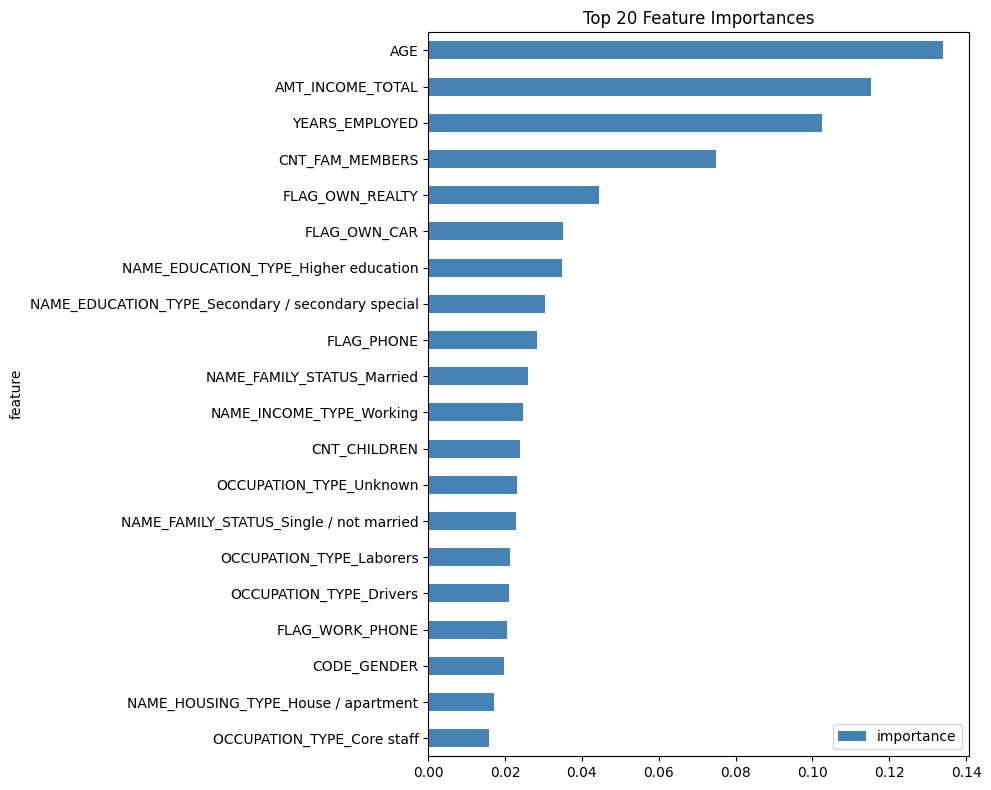

In [19]:
from sklearn.feature_selection import RFE

# Get feature importances from best model
rf_best = search.best_estimator_.named_steps['model']
feature_names = X_train.columns.tolist()
importances = rf_best.feature_importances_

# Sort by importance
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 15 features:")
print(feat_imp.head(15))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', x='feature', y='importance', 
                        ax=ax, color='steelblue')
ax.set_title("Top 20 Feature Importances")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# Get best params without n_estimators (already set explicitly)

rfecv = RFECV(
    estimator=RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1,
        **best_params
    ),
    step=3,
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rfecv.fit(X_train, y_train)

print(f"\nOptimal number of features: {rfecv.n_features_}")
print(f"Best ROC-AUC with optimal features: {rfecv.cv_results_['mean_test_score'].max():.4f}")

Fitting estimator with 46 features.
Fitting estimator with 46 features.Fitting estimator with 46 features.

Fitting estimator with 46 features.
Fitting estimator with 46 features.
Fitting estimator with 43 features.
Fitting estimator with 43 features.
Fitting estimator with 43 features.
Fitting estimator with 43 features.
Fitting estimator with 43 features.
Fitting estimator with 40 features.
Fitting estimator with 40 features.
Fitting estimator with 40 features.
Fitting estimator with 40 features.
Fitting estimator with 40 features.
Fitting estimator with 37 features.
Fitting estimator with 37 features.
Fitting estimator with 37 features.
Fitting estimator with 37 features.
Fitting estimator with 37 features.
Fitting estimator with 34 features.
Fitting estimator with 34 features.
Fitting estimator with 34 features.
Fitting estimator with 34 features.
Fitting estimator with 34 features.
Fitting estimator with 31 features.
Fitting estimator with 31 features.
Fitting estimator with 31 fe

Selected 16 features:
  - CODE_GENDER
  - FLAG_OWN_CAR
  - FLAG_OWN_REALTY
  - CNT_CHILDREN
  - AMT_INCOME_TOTAL
  - FLAG_WORK_PHONE
  - FLAG_PHONE
  - CNT_FAM_MEMBERS
  - AGE
  - YEARS_EMPLOYED
  - NAME_INCOME_TYPE_Pensioner
  - NAME_INCOME_TYPE_Working
  - NAME_EDUCATION_TYPE_Secondary / secondary special
  - NAME_FAMILY_STATUS_Single / not married
  - OCCUPATION_TYPE_Laborers
  - OCCUPATION_TYPE_Unknown


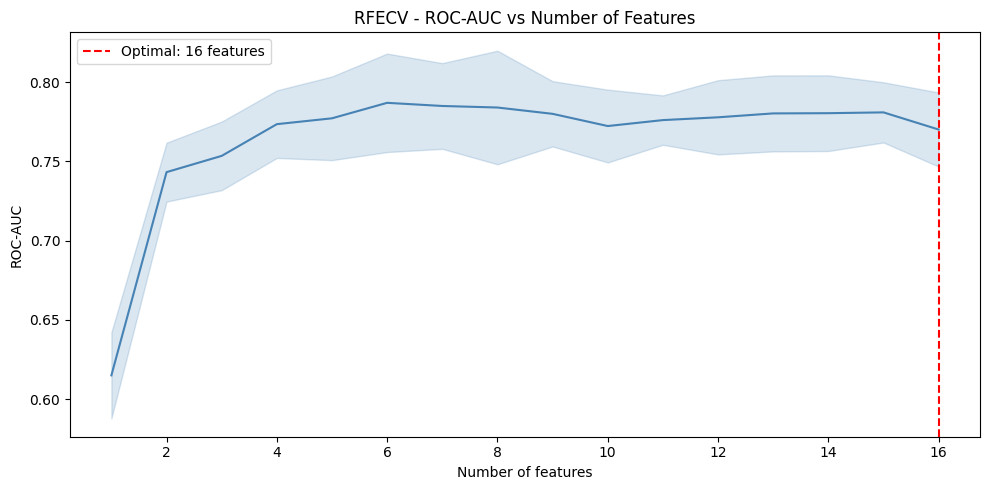

In [24]:
# Selected features
selected_features = X_train.columns[rfecv.support_].tolist()
print(f"Selected {len(selected_features)} features:")
for f in selected_features:
    print(f"  - {f}")

# Plot ROC-AUC vs number of features
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'], color='steelblue')
plt.fill_between(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
                 rfecv.cv_results_['mean_test_score'] - rfecv.cv_results_['std_test_score'],
                 rfecv.cv_results_['mean_test_score'] + rfecv.cv_results_['std_test_score'],
                 alpha=0.2, color='steelblue')
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Optimal: {rfecv.n_features_} features')
plt.xlabel("Number of features")
plt.ylabel("ROC-AUC")
plt.title("RFECV - ROC-AUC vs Number of Features")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Train final model with selected features
X_train_rfe = X_train[selected_features]
X_test_rfe = X_test[selected_features]

final_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, **best_params))
])

final_pipeline.fit(X_train_rfe, y_train)
y_pred_final = final_pipeline.predict(X_test_rfe)
y_prob_final = final_pipeline.predict_proba(X_test_rfe)[:, 1]

print("=== Random Forest - Final (16 features) ===")
print(classification_report(y_test, y_pred_final, target_names=['Good', 'Bad']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_final):.4f}")

=== Random Forest - Final (16 features) ===
              precision    recall  f1-score   support

        Good       0.99      0.99      0.99      7169
         Bad       0.26      0.23      0.24       123

    accuracy                           0.98      7292
   macro avg       0.63      0.61      0.62      7292
weighted avg       0.97      0.98      0.98      7292

ROC-AUC: 0.8216


In [26]:
# ============================================================
# FINAL MODEL SUMMARY
# ============================================================
# Random Forest with 16 features selected by RFECV
# ROC-AUC: 0.8216 vs 0.8242 (46 features) - negligible difference
#
# Key features: AGE, AMT_INCOME_TOTAL, YEARS_EMPLOYED, CNT_FAM_MEMBERS
# Model is simpler, more interpretable and production-ready
#
# Limitations:
# - Only 1.69% bad clients - extreme class imbalance
# - Recall of 0.23 - detects 1 in 4 bad clients
# - SHAP explainability pending (next notebook)
# ============================================================

In [27]:
import pickle

# Save final model pipeline
with open('model_final.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

# Save selected features list
with open('selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

print("Model saved: model_final.pkl")
print("Features saved: selected_features.pkl")

Model saved: model_final.pkl
Features saved: selected_features.pkl
